<a href="https://colab.research.google.com/github/Lavaramaraj/TinyML_Hardware_Accelerator/blob/main/TinyML_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Install dependencies**

In [18]:
!pip install -q tensorflow numpy pandas matplotlib

**Cell 2 — Import libraries**

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

print("==========================================")
print(" TinyML Hardware Accelerator")
print("==========================================")
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("==========================================")

 TinyML Hardware Accelerator
TensorFlow: 2.20.0
NumPy: 2.1.3


**Cell 3 — Create Edge-IoT dataset**

In [20]:
data = {
    "Temperature": [
        24, 25, 26, 25, 27,
        23, 26, 24, 25, 27,
        70, 75, 80, 72, 78,
        82, 76, 85, 73, 80
    ],

    "Vibration": [
        9, 10, 12, 11, 13,
        8, 11, 10, 12, 9,
        80, 85, 90, 88, 82,
        92, 86, 95, 84, 90
    ],

    "Humidity": [
        48, 50, 52, 51, 49,
        47, 53, 50, 48, 51,
        90, 92, 95, 91, 94,
        96, 93, 97, 89, 95
    ],

    "Class": [
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
display(df)

Dataset:


,Temperature,Vibration,Humidity,Class
0,24,9,48,0
1,25,10,50,0
2,26,12,52,0
3,25,11,51,0
4,27,13,49,0
5,23,8,47,0
6,26,11,53,0
7,24,10,50,0
8,25,12,48,0
9,27,9,51,0


**Cell 4 — Visualize sensor data**

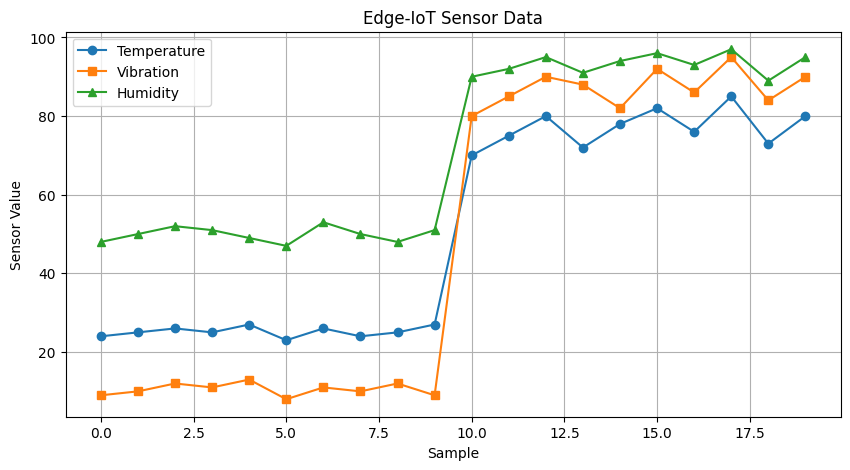

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["Temperature"],
    marker="o",
    label="Temperature"
)

plt.plot(
    df["Vibration"],
    marker="s",
    label="Vibration"
)

plt.plot(
    df["Humidity"],
    marker="^",
    label="Humidity"
)

plt.xlabel("Sample")
plt.ylabel("Sensor Value")
plt.title("Edge-IoT Sensor Data")
plt.legend()
plt.grid(True)

plt.show()

**Cell 5 — Prepare data**

In [22]:
X = df[
    ["Temperature", "Vibration", "Humidity"]
].values.astype(np.float32)

y = df["Class"].values.astype(np.int32)

# Normalize values
X = X / 100.0

print("Input shape :", X.shape)
print("Output shape:", y.shape)

print("\nInput samples:")
print(X[:5])

print("\nLabels:")
print(y)

Input shape : (20, 3)
Output shape: (20,)

Input samples:
[[0.24 0.09 0.48]
 [0.25 0.1  0.5 ]
 [0.26 0.12 0.52]
 [0.25 0.11 0.51]
 [0.27 0.13 0.49]]

Labels:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


**Cell 6 — Create TinyML neural network**

In [23]:
model = keras.Sequential([
    keras.layers.Input(
        shape=(3,),
        name="sensor_input"
    ),

    keras.layers.Dense(
        4,
        activation="relu",
        name="hidden_layer"
    ),

    keras.layers.Dense(
        2,
        activation="softmax",
        name="output_layer"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

**Cell 7 — Train model**

In [24]:
print("Training TinyML model...")

history = model.fit(
    X,
    y,
    epochs=300,
    batch_size=4,
    verbose=0
)

print("Training completed.")

Training TinyML model...
Training completed.


**Cell 8 — Show accuracy**

In [25]:
loss, accuracy = model.evaluate(
    X,
    y,
    verbose=0
)

print("==========================================")
print(" TINYML MODEL RESULT")
print("==========================================")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Loss     : {loss:.6f}")
print("==========================================")

 TINYML MODEL RESULT
Accuracy : 100.00%
Loss     : 0.083240


**Cell 9 — Accuracy graph**

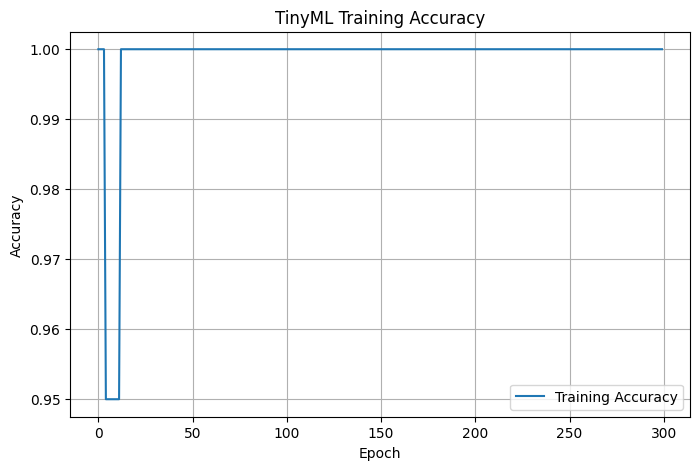

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TinyML Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()

**Cell 10 — Loss graph**

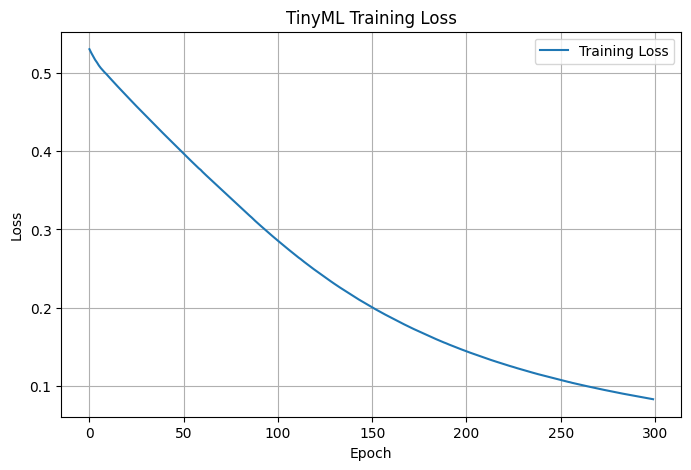

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TinyML Training Loss")
plt.legend()
plt.grid(True)

plt.show()

**Cell 11 — Test predictions**

In [28]:
test_data = np.array([
    [25, 10, 50],
    [80, 90, 95],
    [30, 20, 55],
    [75, 85, 92],
    [26, 11, 51],
    [82, 88, 94]
], dtype=np.float32)

test_normalized = test_data / 100.0

predictions = model.predict(
    test_normalized,
    verbose=0
)

print("==========================================")
print(" TINYML PREDICTION")
print("==========================================")

for i in range(len(test_data)):

    class_id = np.argmax(predictions[i])

    confidence = predictions[i][class_id] * 100

    if class_id == 0:
        result = "NORMAL"
    else:
        result = "ANOMALY"

    print(
        f"Sample {i+1}: "
        f"T={test_data[i][0]:.0f}, "
        f"V={test_data[i][1]:.0f}, "
        f"H={test_data[i][2]:.0f}"
        f" --> {result}"
        f" ({confidence:.2f}%)"
    )

print("==========================================")

 TINYML PREDICTION
Sample 1: T=25, V=10, H=50 --> NORMAL (85.88%)
Sample 2: T=80, V=90, H=95 --> ANOMALY (99.10%)
Sample 3: T=30, V=20, H=55 --> NORMAL (76.68%)
Sample 4: T=75, V=85, H=92 --> ANOMALY (98.57%)
Sample 5: T=26, V=11, H=51 --> NORMAL (85.88%)
Sample 6: T=82, V=88, H=94 --> ANOMALY (99.05%)


**Cell 12 — Save model**

In [29]:
model.save("tinyml_model.keras")

print("Model saved successfully:")
print("tinyml_model.keras")

Model saved successfully:
tinyml_model.keras


**Cell 13 — INT8 Quantization**

In [30]:
def representative_dataset():

    for sample in X:
        yield [sample.reshape(1, 3)]


converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open(
    "tinyml_int8.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print("==========================================")
print(" INT8 QUANTIZATION")
print("==========================================")
print(
    "INT8 Model Size:",
    len(tflite_model),
    "bytes"
)
print("File: tinyml_int8.tflite")
print("==========================================")

Saved artifact at '/tmp/tmp8fr55xsq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  132198715435408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132198715435216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132198715814160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132198715436176: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


 INT8 QUANTIZATION
INT8 Model Size: 2160 bytes
File: tinyml_int8.tflite


**Cell 14 — Compare model size**

In [31]:
keras_size = os.path.getsize(
    "tinyml_model.keras"
)

int8_size = os.path.getsize(
    "tinyml_int8.tflite"
)

print("==========================================")
print(" MODEL SIZE")
print("==========================================")
print(f"Keras Model : {keras_size / 1024:.2f} KB")
print(f"INT8 Model  : {int8_size / 1024:.2f} KB")
print("==========================================")

 MODEL SIZE
Keras Model : 20.81 KB
INT8 Model  : 2.11 KB


**Cell 15 — Verify INT8 model**

In [32]:
interpreter = tf.lite.Interpreter(
    model_path="tinyml_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("==========================================")
print(" INT8 MODEL DETAILS")
print("==========================================")

print("Input type :",
      input_details[0]["dtype"])

print("Output type:",
      output_details[0]["dtype"])

print("Input shape:",
      input_details[0]["shape"])

print("Output shape:",
      output_details[0]["shape"])

print("==========================================")

 INT8 MODEL DETAILS
Input type : <class 'numpy.int8'>
Output type: <class 'numpy.int8'>
Input shape: [1 3]
Output shape: [1 2]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


**Cell 16 — INT8 prediction**

In [33]:
input_info = input_details[0]
output_info = output_details[0]

input_scale, input_zero_point = (
    input_info["quantization"]
)

output_scale, output_zero_point = (
    output_info["quantization"]
)

print("Input scale     :", input_scale)
print("Input zero point:", input_zero_point)

print("\n==========================================")
print(" INT8 INFERENCE")
print("==========================================")

for i in range(len(test_normalized)):

    sample = test_normalized[i:i+1]

    # Convert floating point to INT8
    quantized_input = (
        sample / input_scale
        + input_zero_point
    )

    quantized_input = np.clip(
        quantized_input,
        -128,
        127
    ).astype(np.int8)

    interpreter.set_tensor(
        input_info["index"],
        quantized_input
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_info["index"]
    )

    predicted_class = np.argmax(output)

    if predicted_class == 0:
        result = "NORMAL"
    else:
        result = "ANOMALY"

    print(
        f"Sample {i+1} --> {result}"
    )

print("==========================================")

Input scale     : 0.0038039216306060553
Input zero point: -128

 INT8 INFERENCE
Sample 1 --> NORMAL
Sample 2 --> ANOMALY
Sample 3 --> NORMAL
Sample 4 --> ANOMALY
Sample 5 --> NORMAL
Sample 6 --> ANOMALY


**Cell 17 — Extract neural-network weights**

In [34]:
print("==========================================")
print(" NEURAL NETWORK WEIGHTS")
print("==========================================")

for layer in model.layers:

    weights = layer.get_weights()

    if len(weights) == 2:

        weight_matrix = weights[0]
        bias = weights[1]

        print("\nLayer:", layer.name)

        print("Weight shape:",
              weight_matrix.shape)

        print("Weights:")
        print(weight_matrix)

        print("\nBias:")
        print(bias)

print("==========================================")

 NEURAL NETWORK WEIGHTS

Layer: hidden_layer
Weight shape: (3, 4)
Weights:
[[ 0.72959054 -0.19765002  1.259189   -0.2182058 ]
 [-0.09606111 -0.6443117   1.3731701   1.7913494 ]
 [-0.6790988  -0.7346881  -0.42529684  0.7397351 ]]

Bias:
[ 0.         0.        -0.2755667 -0.5363368]

Layer: output_layer
Weight shape: (4, 2)
Weights:
[[ 0.83867526 -0.28311038]
 [ 0.47511578  0.0592351 ]
 [-1.5145627   1.387958  ]
 [-0.87679476  0.35121775]]

Bias:
[ 0.9027336 -0.9027336]


**Cell 18 — Generate SystemVerilog weights**

In [35]:
layers_with_weights = [
    layer
    for layer in model.layers
    if len(layer.get_weights()) == 2
]

dense1 = layers_with_weights[0]
dense2 = layers_with_weights[1]

w1, b1 = dense1.get_weights()
w2, b2 = dense2.get_weights()


def quantize_to_int8(values):

    max_value = np.max(
        np.abs(values)
    )

    if max_value == 0:
        scale = 1.0
    else:
        scale = 127.0 / max_value

    quantized = np.round(
        values * scale
    )

    quantized = np.clip(
        quantized,
        -128,
        127
    )

    return quantized.astype(np.int8), scale


qw1, scale1 = quantize_to_int8(w1)
qb1, _ = quantize_to_int8(b1)

qw2, scale2 = quantize_to_int8(w2)
qb2, _ = quantize_to_int8(b2)


with open(
    "model_weights.svh",
    "w"
) as f:

    f.write("// TinyML Hardware Accelerator\n")
    f.write("// Auto-generated from trained model\n\n")

    f.write("parameter int INPUTS = 3;\n")
    f.write("parameter int HIDDEN = 4;\n")
    f.write("parameter int OUTPUTS = 2;\n\n")

    # First layer weights
    f.write(
        "parameter signed [7:0] "
        "W1 [0:2][0:3] = '{\n"
    )

    for i in range(3):

        f.write("'{")

        for j in range(4):

            f.write(
                str(int(qw1[i][j]))
            )

            if j < 3:
                f.write(", ")

        f.write("}")

        if i < 2:
            f.write(",\n")

    f.write("\n};\n\n")

    # First layer bias
    f.write(
        "parameter signed [7:0] "
        "B1 [0:3] = '{"
    )

    for i in range(4):

        f.write(
            str(int(qb1[i]))
        )

        if i < 3:
            f.write(", ")

    f.write("};\n\n")

    # Second layer weights
    f.write(
        "parameter signed [7:0] "
        "W2 [0:3][0:1] = '{\n"
    )

    for i in range(4):

        f.write("'{")

        for j in range(2):

            f.write(
                str(int(qw2[i][j]))
            )

            if j < 1:
                f.write(", ")

        f.write("}")

        if i < 3:
            f.write(",\n")

    f.write("\n};\n\n")

    # Second layer bias
    f.write(
        "parameter signed [7:0] "
        "B2 [0:1] = '{"
    )

    for i in range(2):

        f.write(
            str(int(qb2[i]))
        )

        if i < 1:
            f.write(", ")

    f.write("};\n")


print("==========================================")
print(" SYSTEMVERILOG FILE GENERATED")
print("==========================================")
print("File created: model_weights.svh")
print("==========================================")

 SYSTEMVERILOG FILE GENERATED
File created: model_weights.svh


**Cell 19 — Display the generated hardware weights**

In [36]:
with open(
    "model_weights.svh",
    "r"
) as f:

    hardware_weights = f.read()

print(hardware_weights)

// TinyML Hardware Accelerator
// Auto-generated from trained model

parameter int INPUTS = 3;
parameter int HIDDEN = 4;
parameter int OUTPUTS = 2;

parameter signed [7:0] W1 [0:2][0:3] = '{
'{52, -14, 89, -15},
'{-7, -46, 97, 127},
'{-48, -52, -30, 52}
};

parameter signed [7:0] B1 [0:3] = '{0, 0, -65, -127};

parameter signed [7:0] W2 [0:3][0:1] = '{
'{70, -24},
'{40, 5},
'{-127, 116},
'{-74, 29}
};

parameter signed [7:0] B2 [0:1] = '{127, -127};



**Cell 20 — Final project summary**

In [37]:
print("""
=====================================================
       TINYML HARDWARE ACCELERATOR
=====================================================

Application:
Edge-IoT Sensor Anomaly Detection

Input Sensors:
- Temperature
- Vibration
- Humidity

ML Model:
Small Fully Connected Neural Network

Software:
Python + TensorFlow

Optimization:
INT8 Quantization

Hardware:
SystemVerilog RTL

Hardware Computation:
Multiply-Accumulate (MAC)

Generated File:
model_weights.svh

Next Stage:
SystemVerilog RTL
        ↓
Vivado Simulation
        ↓
Synthesis
        ↓
Area / Timing / Power
=====================================================
""")


       TINYML HARDWARE ACCELERATOR

Application:
Edge-IoT Sensor Anomaly Detection

Input Sensors:
- Temperature
- Vibration
- Humidity

ML Model:
Small Fully Connected Neural Network

Software:
Python + TensorFlow

Optimization:
INT8 Quantization

Hardware:
SystemVerilog RTL

Hardware Computation:
Multiply-Accumulate (MAC)

Generated File:
model_weights.svh

Next Stage:
SystemVerilog RTL
        ↓
Vivado Simulation
        ↓
Synthesis
        ↓
Area / Timing / Power

